<h1><center>EE69210: Machine Learning for Signal Processing Laboratory</center></h1>
<h2><center>Experiment-7: Polynomial Regression </center></h2>
<h3><center>Anirvan Krishna | 21EE38002</center></h3>

In [30]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# Dataset generation and visualization

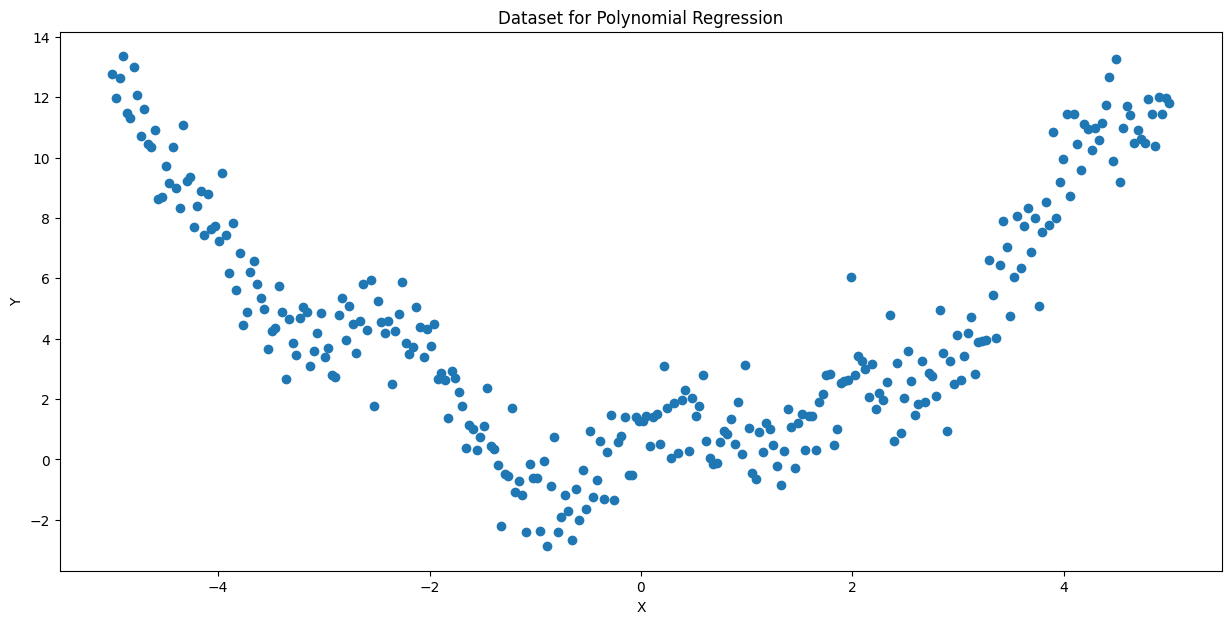

In [5]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate x values
x = np.linspace(-5, 5, 300).reshape((-1, 1))

# Generate y values using a combination of sine, cosine, and polynomial functions with added noise
noise = np.random.normal(0, 1, x.shape)
y_true = np.sin(2 * x) + 0.5 * x**2 + np.cos(3 * x)
y_noisy = y_true + noise

y = y_noisy.reshape((-1, 1))

# Plot the true function and the different models
plt.figure(figsize=(15, 7))
plt.scatter(x, y_noisy)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Dataset for Polynomial Regression')
plt.show()

In [9]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Polynomial Regression

In [ ]:
class PolynomialRegression:
    
    def __init__(self, degree):
        self.degree = degree
        self.coefficients = None
        self.gd_loss = []
        self.gd_mae = []
        self.gd_mape = []

    def fit_normal_equation(self, x, y):
        X = np.vander(x.flatten(), N=self.degree + 1, increasing=True)
        self.coefficients = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

    def fit_gradient_descent(self, x, y, learning_rate=0.01, n_iters=1000):
        
        X = np.vander(x.flatten(), N=self.degree + 1, increasing=True)
        
        n_samples, n_features = X.shape
        
        self.coefficients = np.random.randn(n_features, 1)
        
        for _ in range(n_iters):
            
            y_pred = X.dot(self.coefficients)
            residuals = y_pred - y
            loss = np.mean(residuals**2)
            mae = mean_absolute_error(y, y_pred)
            mape = mean_absolute_percentage_error(y, y_pred)
            self.gd_loss.append(loss)
            self.gd_mae.append(mae)
            self.gd_mape.append(mape)

            gradients = 1/n_samples * X.T.dot(X.dot(self.coefficients) - y)
            self.coefficients -= learning_rate * gradients

    def predict(self, x):
        X = np.vander(x.flatten(), N=self.degree + 1, increasing=True)
        return X.dot(self.coefficients)

### Fitting Normal Equation

In [32]:
model = PolynomialRegression(degree=2)
model.fit_normal_equation(X_train_scaled, y_train)

In [33]:
y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'Mean Absolute Error: {mae:.2f}')
print(f'Mean Absolute Percentage Error: {mape:.2f}')
print(f'Mean Squared Error: {mse:.2f}')

Mean Absolute Error: 1.07
Mean Absolute Percentage Error: 0.80
Mean Squared Error: 1.82


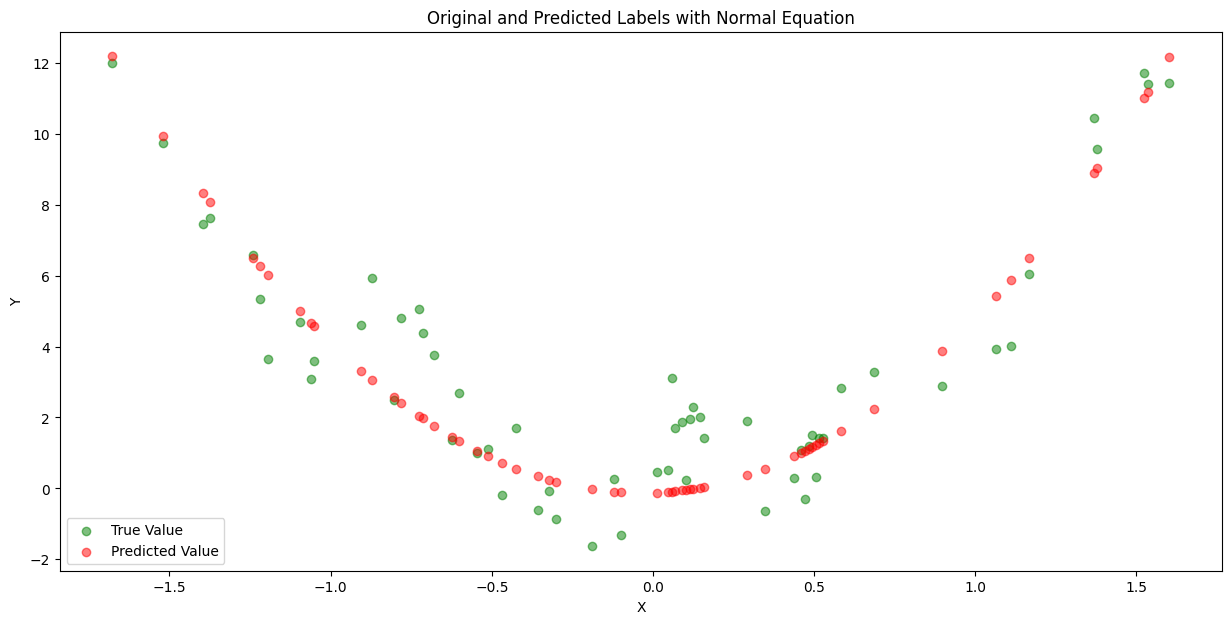

In [44]:
y_pred = model.predict(X_test_scaled)

plt.figure(figsize=(15, 7))

plt.scatter(X_test_scaled, y_test, label='True Value', color='green', alpha=0.5)
plt.scatter(X_test_scaled, y_pred, label='Predicted Value', color='red', alpha=0.5)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Original and Predicted Labels with Normal Equation')
plt.legend()
plt.show()

### Fitting Gradient Descent

In [40]:
model2 = PolynomialRegression(degree=2)
model2.fit_gradient_descent(X_train_scaled, y_train, learning_rate=0.01, n_iters=500)

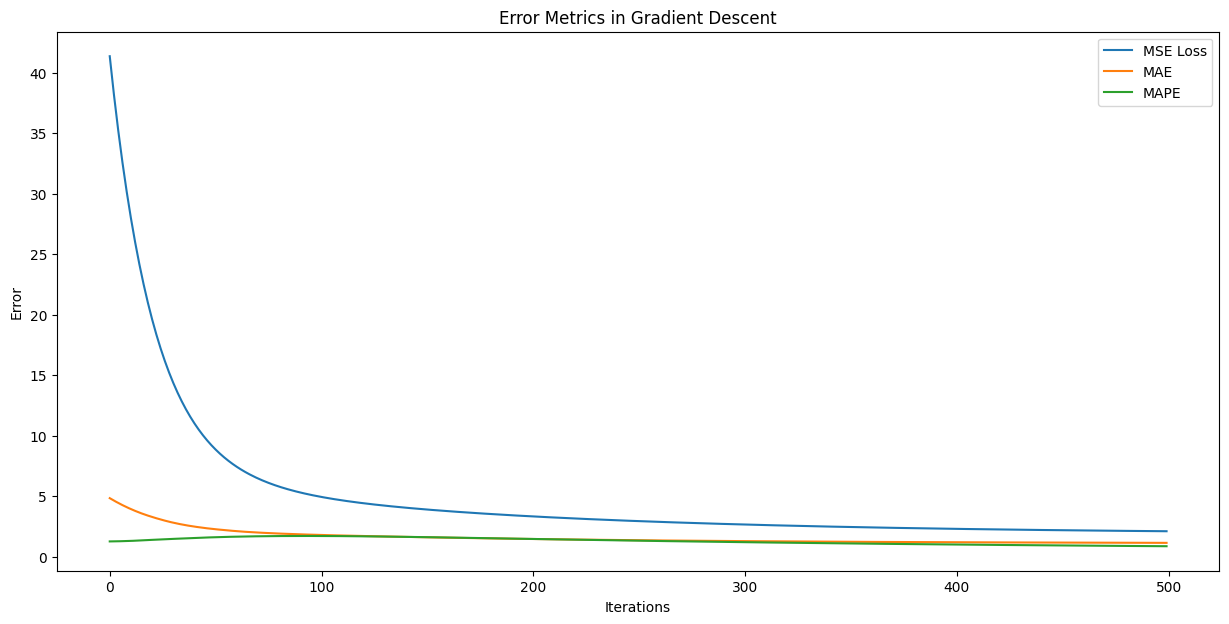

In [41]:
plt.figure(figsize=(15, 7))

plt.plot(model2.gd_loss, label='MSE Loss')
plt.plot(model2.gd_mae, label='MAE')
plt.plot(model2.gd_mape, label='MAPE')

plt.xlabel('Iterations')
plt.ylabel('Error')
plt.title('Error Metrics in Gradient Descent')
plt.legend()

In [42]:
y_pred = model2.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'Mean Absolute Error: {mae:.2f}')
print(f'Mean Absolute Percentage Error: {mape:.2f}')
print(f'Mean Squared Error: {mse:.2f}')

Mean Absolute Error: 1.08
Mean Absolute Percentage Error: 1.16
Mean Squared Error: 1.65


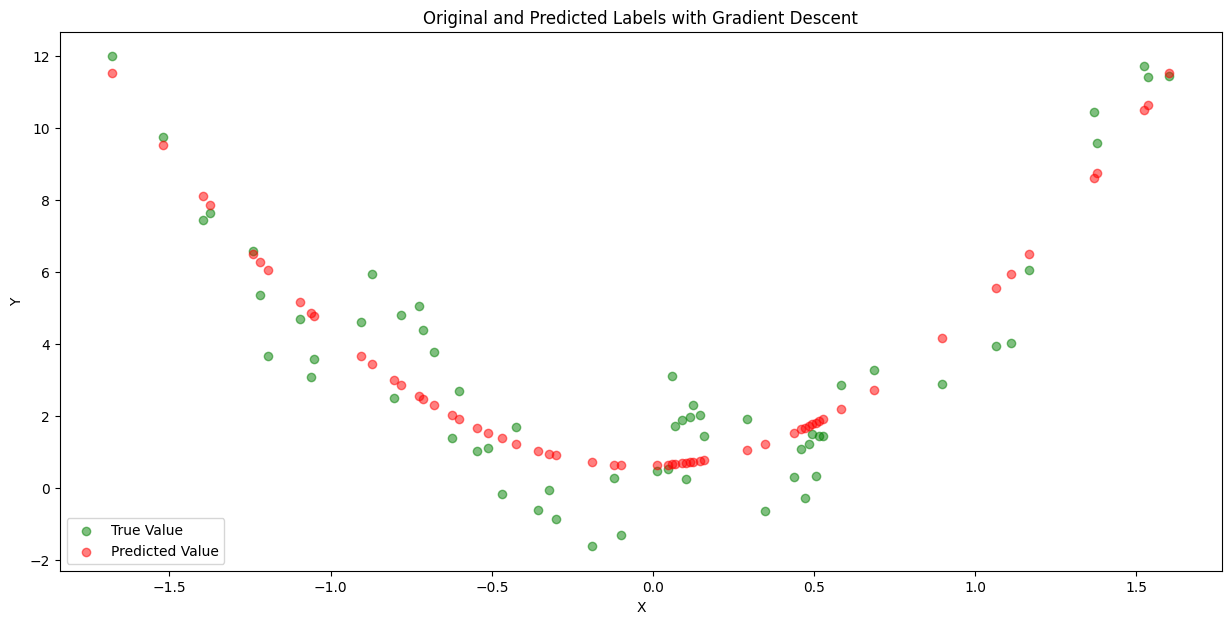

In [43]:
y_pred = model2.predict(X_test_scaled)

plt.figure(figsize=(15, 7))

plt.scatter(X_test_scaled, y_test, label='True Value', color='green', alpha=0.5)
plt.scatter(X_test_scaled, y_pred, label='Predicted Value', color='red', alpha=0.5)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Original and Predicted Labels with Gradient Descent')
plt.legend()
plt.show()